In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import linear_model

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(URL)
df.sample(5)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
664,2014,LEXUS,IS 250 C,SUBCOMPACT,2.5,6,AS6,Z,11.2,7.8,9.7,29,223
396,2014,FORD,FIESTA ST,COMPACT,1.6,4,M6,X,8.9,6.8,8.0,35,184
576,2014,JEEP,CHEROKEE TRAILHAWK 4X4,SUV - SMALL,3.2,6,A9,X,13.4,9.5,11.6,24,267
657,2014,LEXUS,ES 350,MID-SIZE,3.5,6,AS6,X,11.3,7.6,9.6,29,221
744,2014,MERCEDES-BENZ,E 350 CABRIOLET,SUBCOMPACT,3.5,6,AS7,Z,12.0,8.5,10.4,27,239


In [2]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [3]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.sample(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
959,2.5,4,9.8,225
915,3.6,6,17.8,285
506,5.0,8,13.2,304
632,2.4,4,10.7,246
244,5.3,8,13.0,299
933,2.5,4,9.0,207
378,3.7,6,16.5,264
360,2.0,4,10.0,230
291,3.6,6,12.0,276


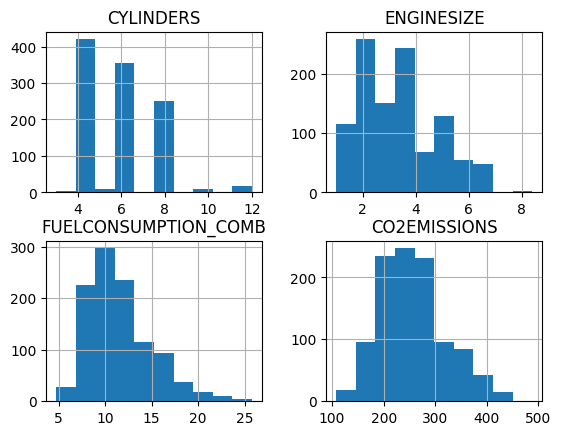

In [4]:
viz = cdf[['CYLINDERS','ENGINESIZE','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
viz.hist()
plt.show()

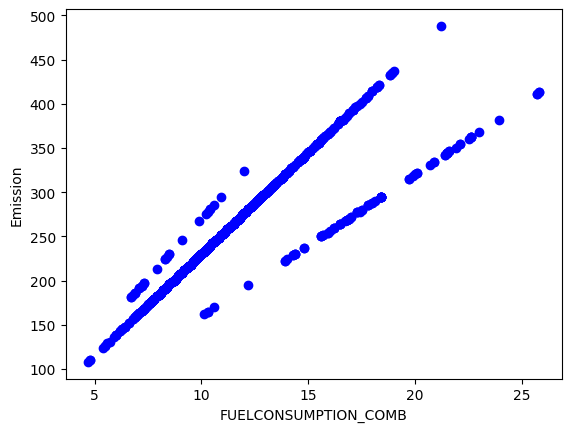

In [5]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS,  color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

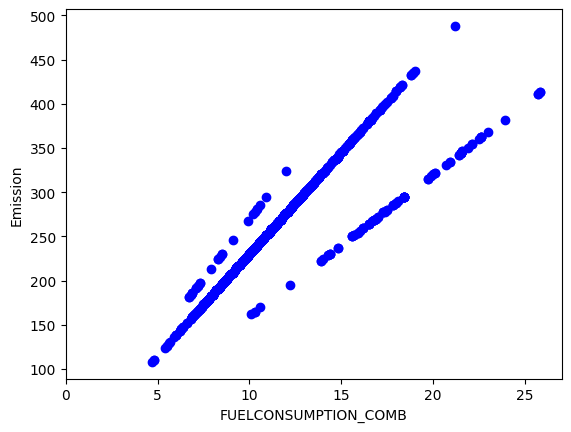

In [6]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('FUELCONSUMPTION_COMB')
plt.ylabel('Emission')
plt.xlim(0,27)
plt.show()

Plot __CYLINDER__ against CO2 Emission, to see how linear their relationship is.


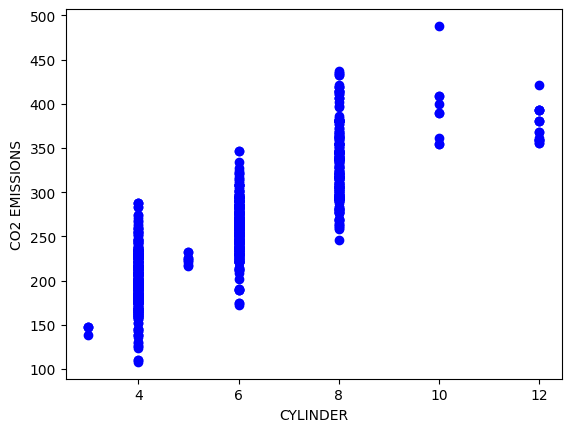

In [7]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel('CYLINDER')
plt.ylabel('CO2 EMISSIONS')
plt.show()

In [8]:
X = cdf.ENGINESIZE.to_numpy()
y = cdf.CO2EMISSIONS.to_numpy()

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state =42)
type(x_train)

numpy.ndarray

In [10]:
np.shape(x_train)

(853,)

In [11]:
lr = linear_model.LinearRegression()
lr.fit(x_train.reshape(-1, 1), y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
print ('Coefficients: ', lr.coef_[0]) # with simple linear regression there is only one coefficient, here we extract it from the 1 by 1 array.
print ('Intercept: ',lr.intercept_)

Coefficients:  38.992978724434074
Intercept:  126.28970217408721


Text(0, 0.5, 'Emission')

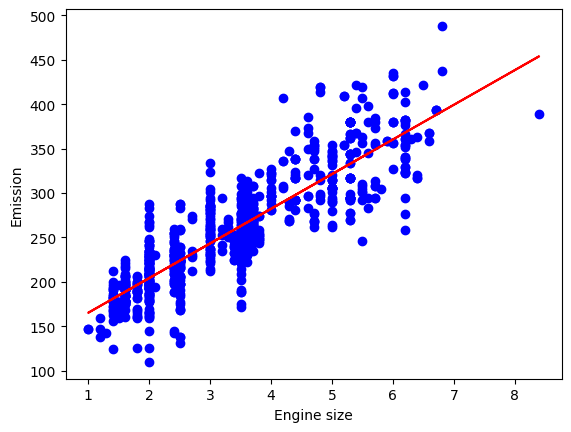

In [13]:
plt.scatter(x_train, y_train,  color='blue')
plt.plot(x_train, lr.coef_ * x_train + lr.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_test_ = lr.predict(x_test.reshape(-1,1))

print("Mean absolute error: %.2f" % mean_absolute_error(y_test, y_test_))
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_test_))
print("Root mean squared error: %.2f" % np.sqrt(mean_squared_error(y_test, y_test_)))
print("R2-score: %.2f" % r2_score(y_test, y_test_))

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76
